# ==========================================================
#  **PROJECT INTRODUCTION**
# ==========================================================
# **Project Title:** **Loan Approval Prediction using** **Machine Learning**




**This project focuses on building a predictive system that determines
whether a loan application will be APPROVED (1) or REJECTED (0) based
on applicant demographic, financial, and credit-related information.**

**The dataset contains 45,000 loan applicant records with 14 features
including Age, Income, Employment Experience, Education, Home Ownership,**
**Loan Amount, Interest Rate, Credit Score, Credit History, and Previous
Loan status**


#**Step 1:** **Import Required Libraries**

#**Insight**
**These libraries help us to:**

**Handle and process data,**
**Create visualizations,
Perform statistical analysis,
Discover hidden patterns**

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================================
# **LOAD DATASET**
# ==========================================================

In [38]:
df = pd.read_csv('loan_data_new.csv')

# **Display first 5 rows**

In [39]:
df.head()

,Age,Gender,Education,Person Income,Employee Experience,Home Onwership,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1


# **Dataset Shape**
**Insights**

Shows total observations and features.
Helps understand dataset size.
Larger datasets generally improve model learning.
Indicates computational requirements

In [40]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 45000
Columns : 14


# **Dataset Information**
**Insights**

Displays column names and data types.
Shows non-null values.
Helps identify missing values.
Useful before preprocessing

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  45000 non-null  int64  
 1   Gender               45000 non-null  object 
 2   Education            45000 non-null  object 
 3   Person Income        45000 non-null  int64  
 4   Employee Experience  45000 non-null  int64  
 5   Home Onwership       45000 non-null  object 
 6   Loan Amount          45000 non-null  int64  
 7   Loan Intent          45000 non-null  object 
 8   Loan interest Rate   45000 non-null  float64
 9   Loan percentage      45000 non-null  float64
 10  Credit History       45000 non-null  int64  
 11  Credit Score         45000 non-null  int64  
 12  Previous Loan        45000 non-null  object 
 13  Loan Status          45000 non-null  int64  
dtypes: float64(2), int64(7), object(5)
memory usage: 4.8+ MB


# **Column Names**

In [42]:
df.columns

Index(['Age', 'Gender', 'Education', 'Person Income', 'Employee Experience',
       'Home Onwership', 'Loan Amount', 'Loan Intent', 'Loan interest Rate',
       'Loan percentage', 'Credit History', 'Credit Score', 'Previous Loan',
       'Loan Status'],
      dtype='object')

**Insights**

Identifies incomplete columns.
Missing values can reduce model performance.
Columns with high missing values need treatment.
Missing values should be handled before training.

# **Missing Values**

In [43]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

,0


# **Missing Value Percentage**

In [44]:
missing_percent = (df.isnull().sum()/len(df))*100

missing_percent = missing_percent[missing_percent>0]

missing_percent.sort_values(ascending=False)

,0


# **Duplicate Values**
**Insights**

Duplicate rows introduce bias.
Removing duplicates improves data quality.
Prevents repeated information.
Leads to more reliable predictions

In [45]:
df = df.drop_duplicates()
df.shape

(45000, 14)

# **Statistical Summary**
**Insights**

Displays mean, median, std, min, and max.
Helps detect unusual values.
Useful for identifying skewness.
Gives a statistical overview

In [46]:
df.describe()

,Age,Person Income,Employee Experience,Loan Amount,Loan interest Rate,Loan percentage,Credit History,Credit Score,Loan Status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [47]:
df.describe(include='all')

,Age,Gender,Education,Person Income,Employee Experience,Home Onwership,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status
count,45000.000000,45000,45000,4.500000e+04,45000.000000,45000,45000.000000,45000,45000.000000,45000.000000,45000.000000,45000.000000,45000,45000.000000
unique,NaN,2,5,NaN,NaN,4,NaN,6,NaN,NaN,NaN,NaN,2,NaN
top,NaN,male,Bachelor,NaN,NaN,RENT,NaN,EDUCATION,NaN,NaN,NaN,NaN,Yes,NaN
freq,NaN,24841,13399,NaN,NaN,23443,NaN,9153,NaN,NaN,NaN,NaN,22858,NaN
mean,27.764178,NaN,NaN,8.031905e+04,5.410333,NaN,9583.157556,NaN,11.006606,0.139725,5.867489,632.608756,NaN,0.222222
std,6.045108,NaN,NaN,8.042250e+04,6.063532,NaN,6314.886691,NaN,2.978808,0.087212,3.879702,50.435865,NaN,0.415744
min,20.000000,NaN,NaN,8.000000e+03,0.000000,NaN,500.000000,NaN,5.420000,0.000000,2.000000,390.000000,NaN,0.000000
25%,24.000000,NaN,NaN,4.720400e+04,1.000000,NaN,5000.000000,NaN,8.590000,0.070000,3.000000,601.000000,NaN,0.000000
50%,26.000000,NaN,NaN,6.704800e+04,4.000000,NaN,8000.000000,NaN,11.010000,0.120000,4.000000,640.000000,NaN,0.000000
75%,30.000000,NaN,NaN,9.578925e+04,8.000000,NaN,12237.250000,NaN,12.990000,0.190000,8.000000,670.000000,NaN,0.000000


# **Data Types**
**Insights**

Separates numerical and categorical features.
Helps choose preprocessing methods.
Numerical features are used for scaling.
Categorical features require encoding

In [48]:
df.dtypes

,0
Age,int64
Gender,object
Education,object
Person Income,int64
Employee Experience,int64
Home Onwership,object
Loan Amount,int64
Loan Intent,object
Loan interest Rate,float64
Loan percentage,float64


# **Numerical Columns**

In [49]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

print(num_cols)

print("Total Numerical Columns :", len(num_cols))

Index(['Age', 'Person Income', 'Employee Experience', 'Loan Amount',
       'Loan interest Rate', 'Loan percentage', 'Credit History',
       'Credit Score', 'Loan Status'],
      dtype='object')
Total Numerical Columns : 9


# **Categorical Columns**

In [50]:
cat_cols = df.select_dtypes(include=['object']).columns

print(cat_cols)

print("Total Categorical Columns :", len(cat_cols))

Index(['Gender', 'Education', 'Home Onwership', 'Loan Intent',
       'Previous Loan'],
      dtype='object')
Total Categorical Columns : 5


# **EDA Visualizations**

# **Histogram (Numerical Features Distribution)**

**Insights**

Histograms show the distribution pattern of each numerical feature.
Symmetric distributions indicate balanced data, while skewed distributions may require transformation.
Features with long tails may contain extreme values.
Helps identify normal and non-normal distributions.
Useful for selecting appropriate preprocessing techniques

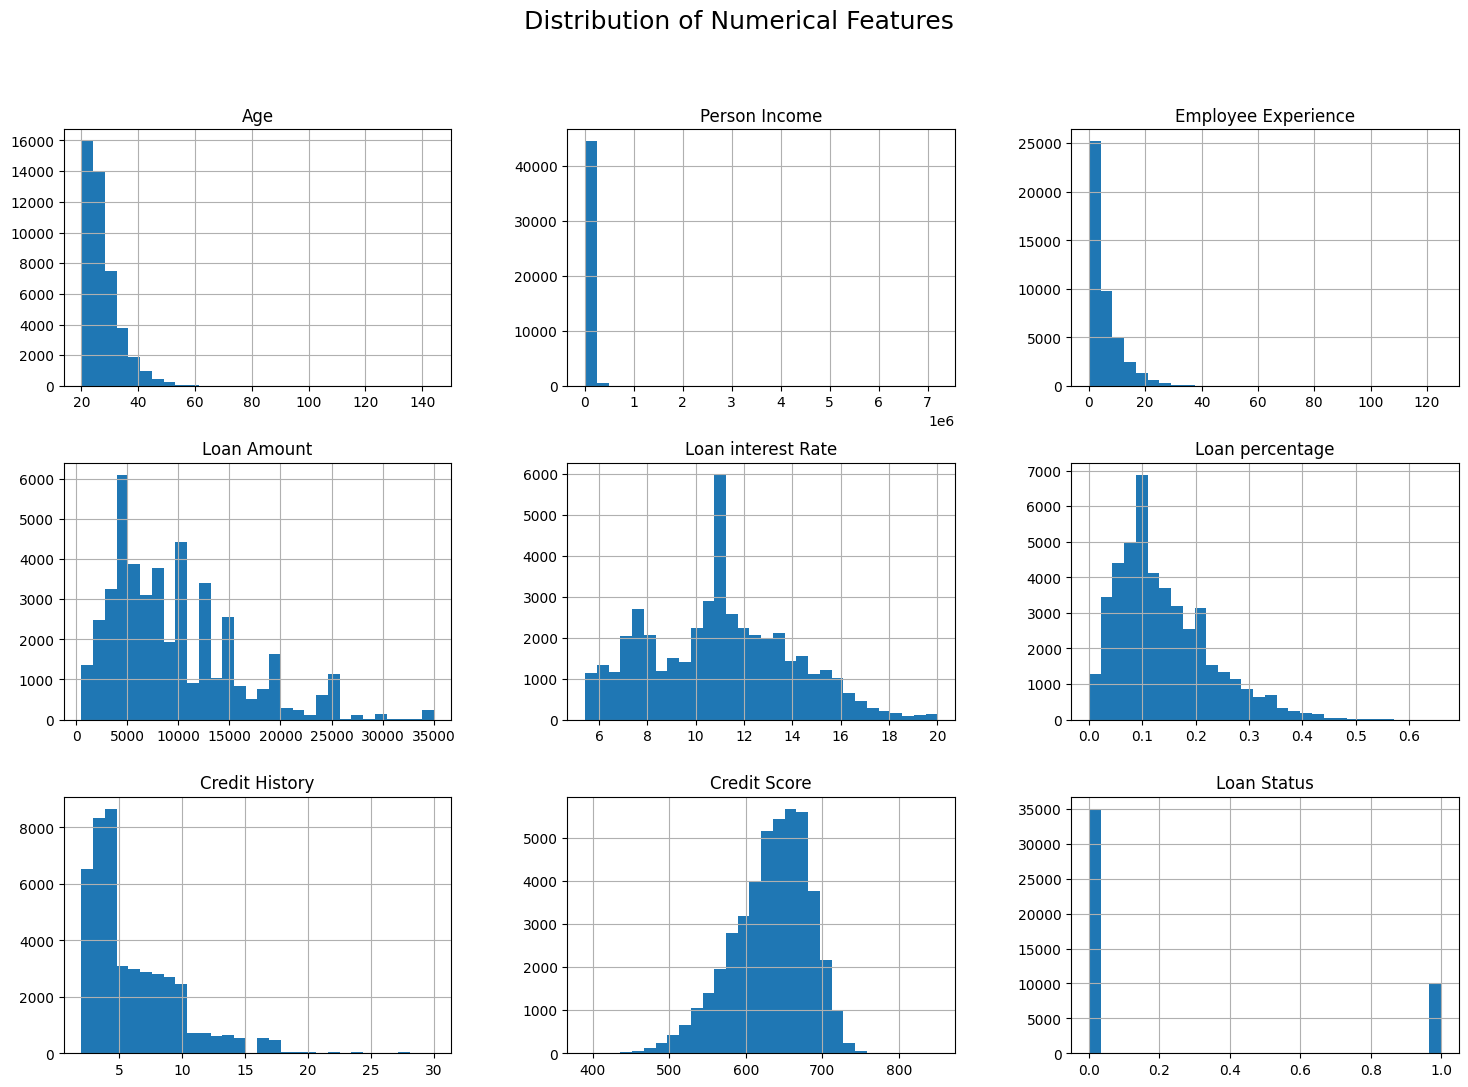

In [51]:
df.hist(figsize=(18,12), bins=30)

plt.suptitle("Distribution of Numerical Features", fontsize=18)

plt.show()

# **Distribution Plot**
**Insights**

KDE curves provide a smooth estimate of data distribution.
Peaks indicate where observations are concentrated.
Skewed distributions suggest possible feature transformation.
Helps understand feature density.
Useful before feature scaling

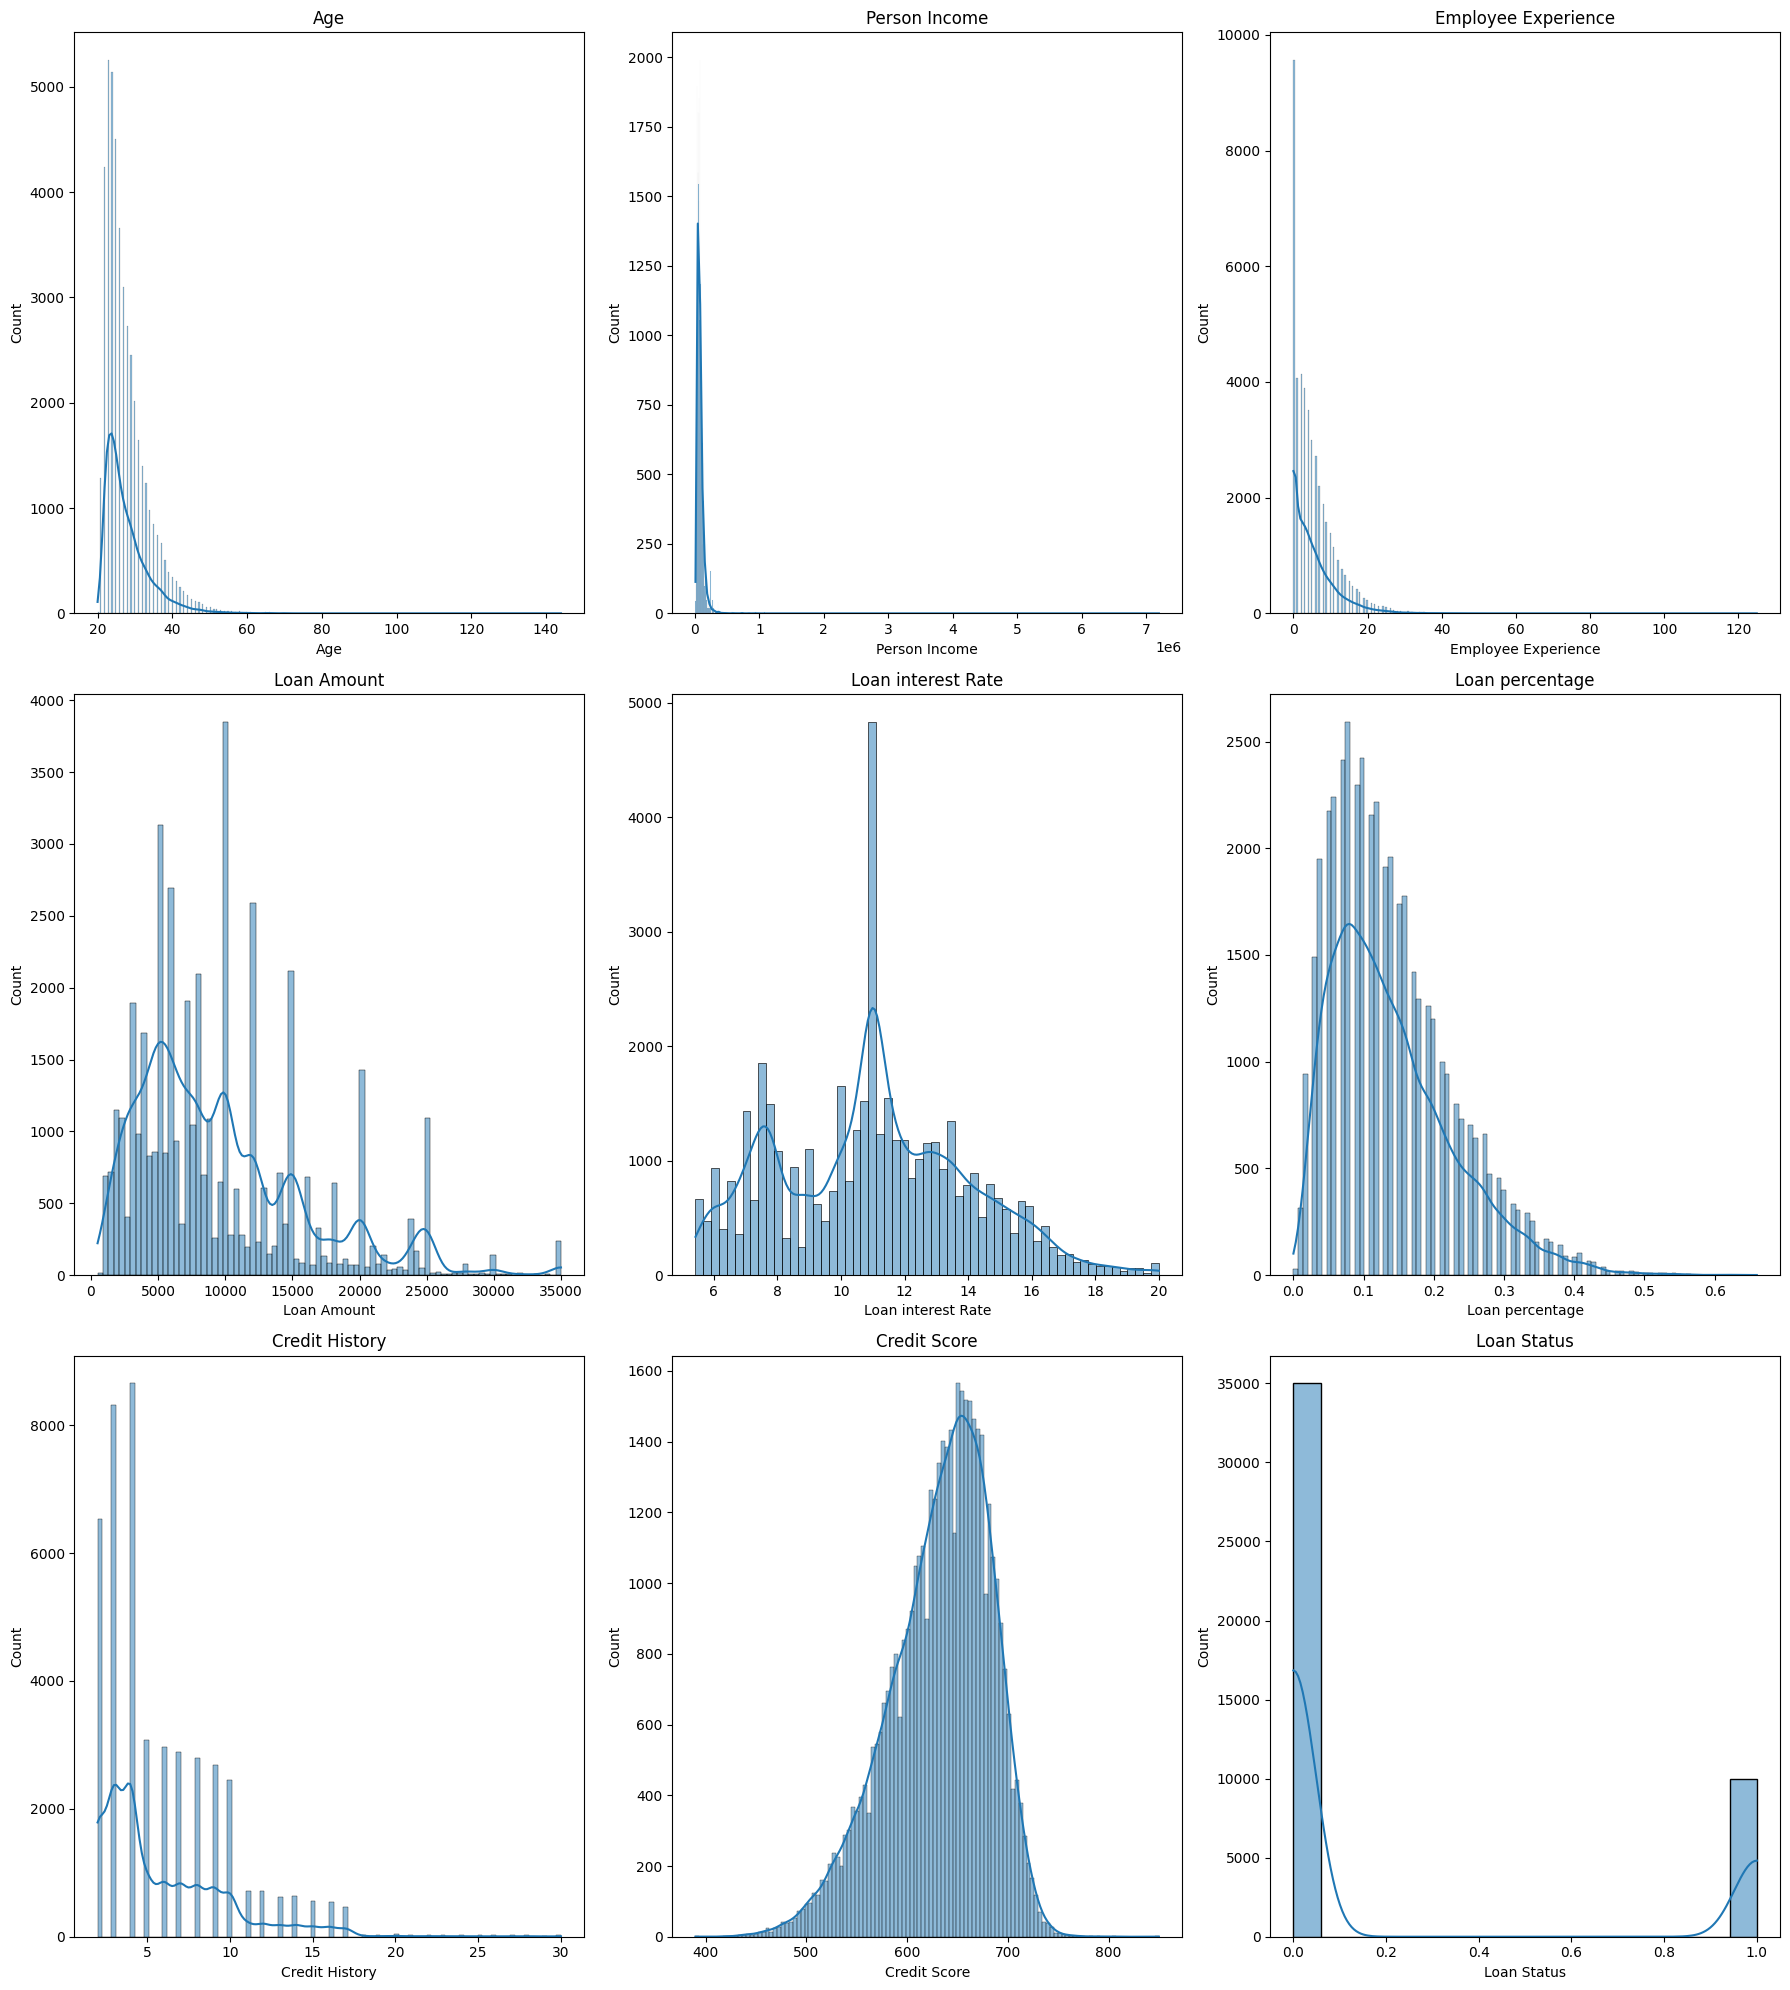

In [52]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(18,20))

for i, col in enumerate(num_cols,1):
    plt.subplot((len(num_cols)+2)//3,3,i)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

# **Boxplot (Outlier Detection)**
**Insights**

Boxplots highlight outliers clearly.
Large whiskers indicate greater variability.
Multiple outliers may influence model performance.
Helps decide whether outlier treatment is required.
Important before model building

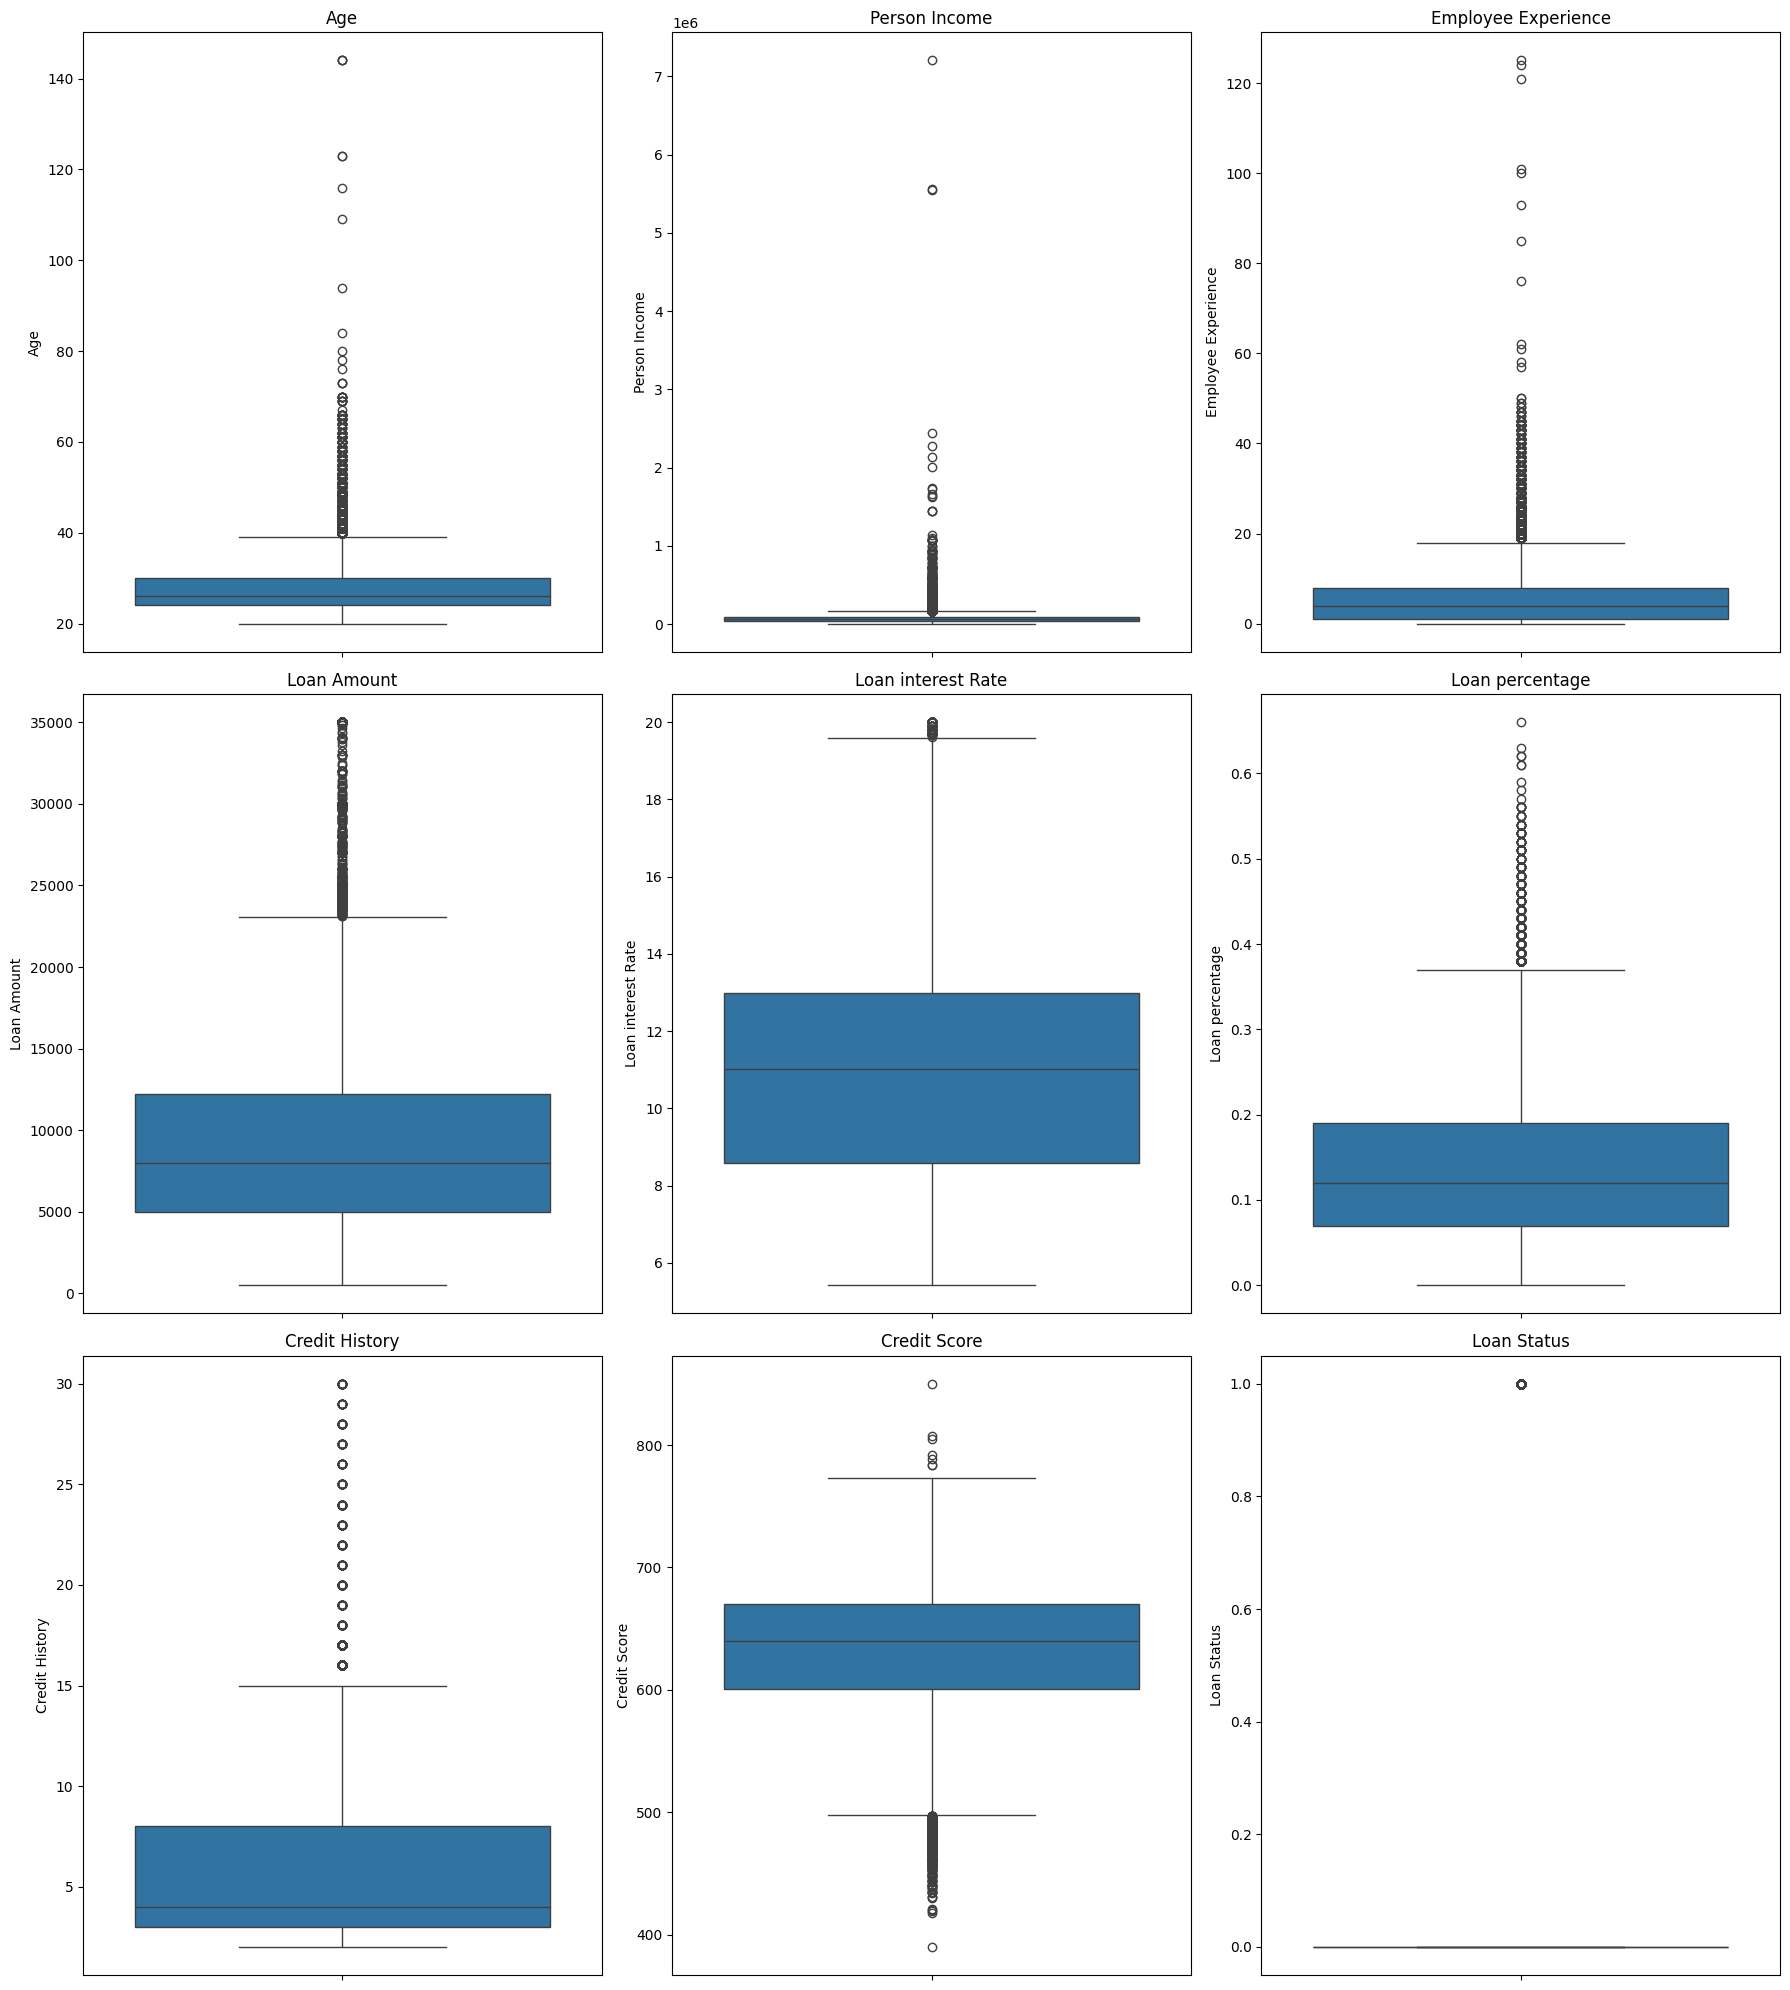

In [53]:

plt.figure(figsize=(18,20))

for i, col in enumerate(num_cols,1):
    plt.subplot((len(num_cols)+2)//3,3,i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

# **Count Plot (Categorical Features)**
**Insights**

Displays category frequency.
Detects class imbalance.
Identifies dominant categories.
Helps understand feature composition.
Useful before encoding categorical variables

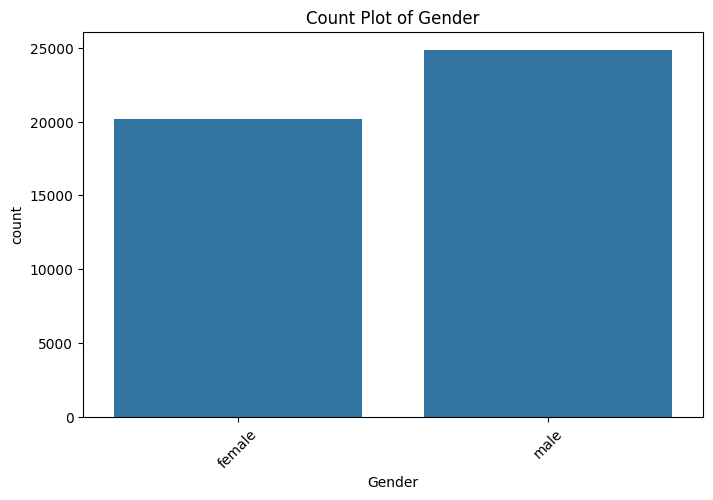

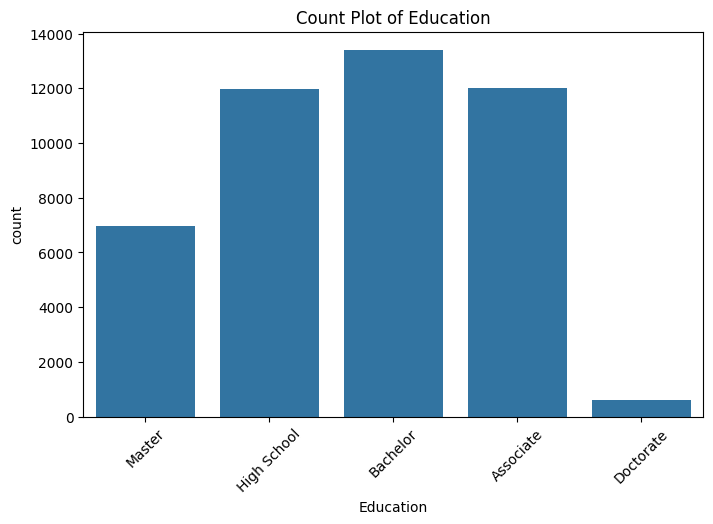

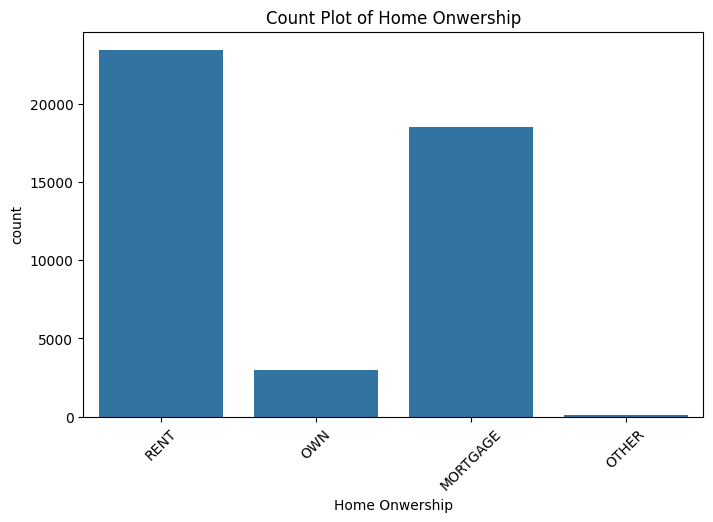

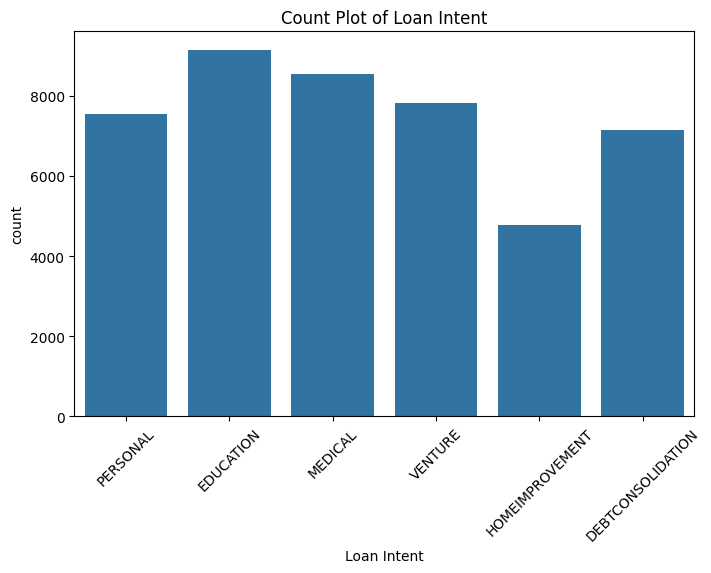

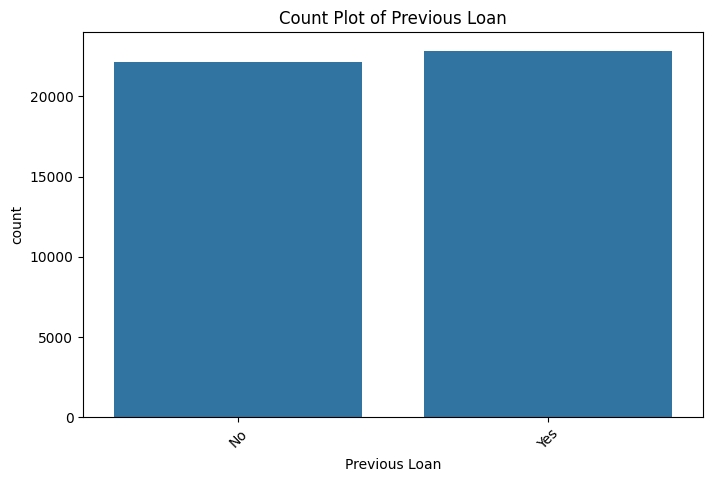

In [54]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:

    plt.figure(figsize=(8,5))

    sns.countplot(data=df, x=col)

    plt.xticks(rotation=45)

    plt.title(f"Count Plot of {col}")

    plt.show()

# **Pie Chart (Categorical Features)**
**Insights**

Shows percentage contribution of each category.
Highlights dominant and minority classes.
Useful for presentation purposes.
Easy visualization of categorical proportions.
Helps identify imbalanced features

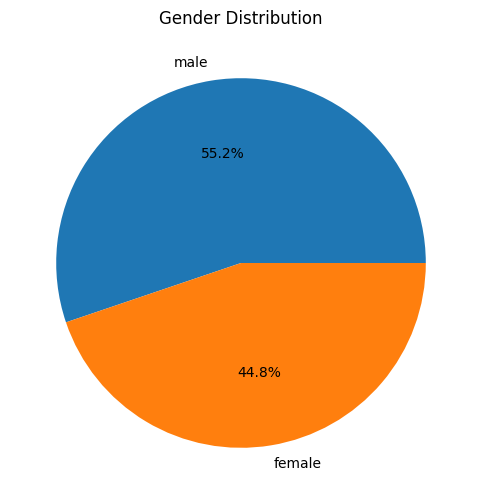

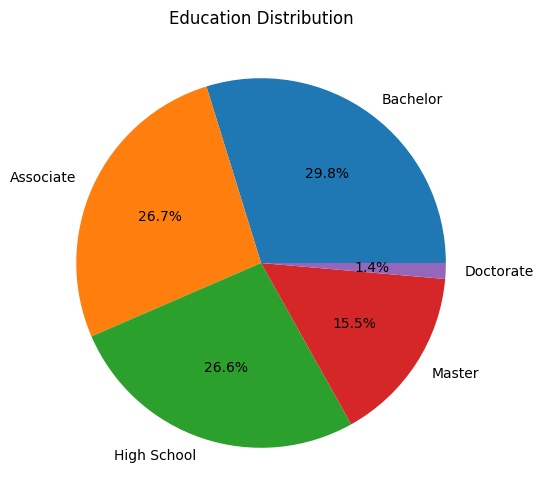

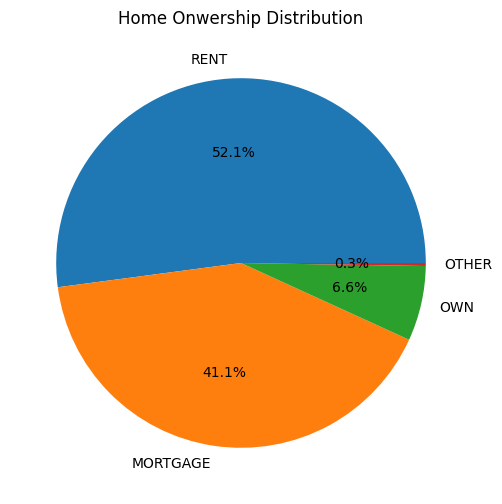

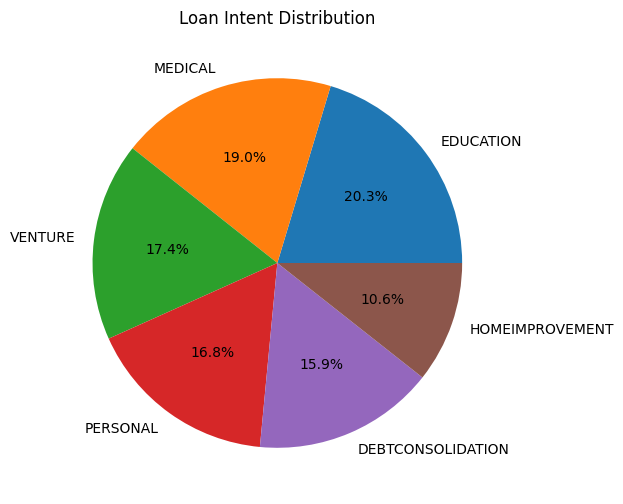

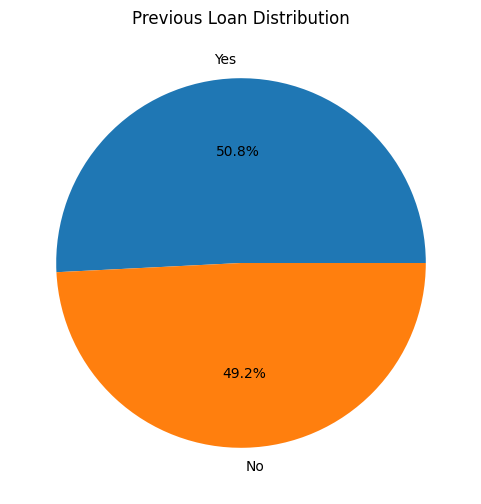

In [55]:
for col in cat_cols:

    plt.figure(figsize=(6,6))

    df[col].value_counts().plot(
        kind='pie',
        autopct='%1.1f%%'
    )

    plt.ylabel("")

    plt.title(f"{col} Distribution")

    plt.show()

# **Correlation Matrix**
**Insights**

Shows relationships between numerical variables.
Positive values indicate direct relationships.
Negative values indicate inverse relationships.
Values near zero indicate weak relationships.
Helps in feature selection

In [56]:

corr = df.corr(numeric_only=True)

corr

,Age,Person Income,Employee Experience,Loan Amount,Loan interest Rate,Loan percentage,Credit History,Credit Score,Loan Status
Age,1.000000,0.193698,0.954412,0.050750,0.013402,-0.043299,0.861985,0.178432,-0.021476
Person Income,0.193698,1.000000,0.185987,0.242290,0.001510,-0.234177,0.124316,0.035919,-0.135808
Employee Experience,0.954412,0.185987,1.000000,0.044589,0.016631,-0.039862,0.824272,0.186196,-0.020481
Loan Amount,0.050750,0.242290,0.044589,1.000000,0.146093,0.593011,0.042969,0.009074,0.107714
Loan interest Rate,0.013402,0.001510,0.016631,0.146093,1.000000,0.125209,0.018008,0.011498,0.332005
Loan percentage,-0.043299,-0.234177,-0.039862,0.593011,0.125209,1.000000,-0.031868,-0.011483,0.384880
Credit History,0.861985,0.124316,0.824272,0.042969,0.018008,-0.031868,1.000000,0.155204,-0.014851
Credit Score,0.178432,0.035919,0.186196,0.009074,0.011498,-0.011483,0.155204,1.000000,-0.007647
Loan Status,-0.021476,-0.135808,-0.020481,0.107714,0.332005,0.384880,-0.014851,-0.007647,1.000000


# **Heatmap**
**Insights**

Strong correlations are easily identified.
Helps detect multicollinearity.
Highly correlated features may be redundant.
Supports feature engineering decisions.
Improves model interpretability

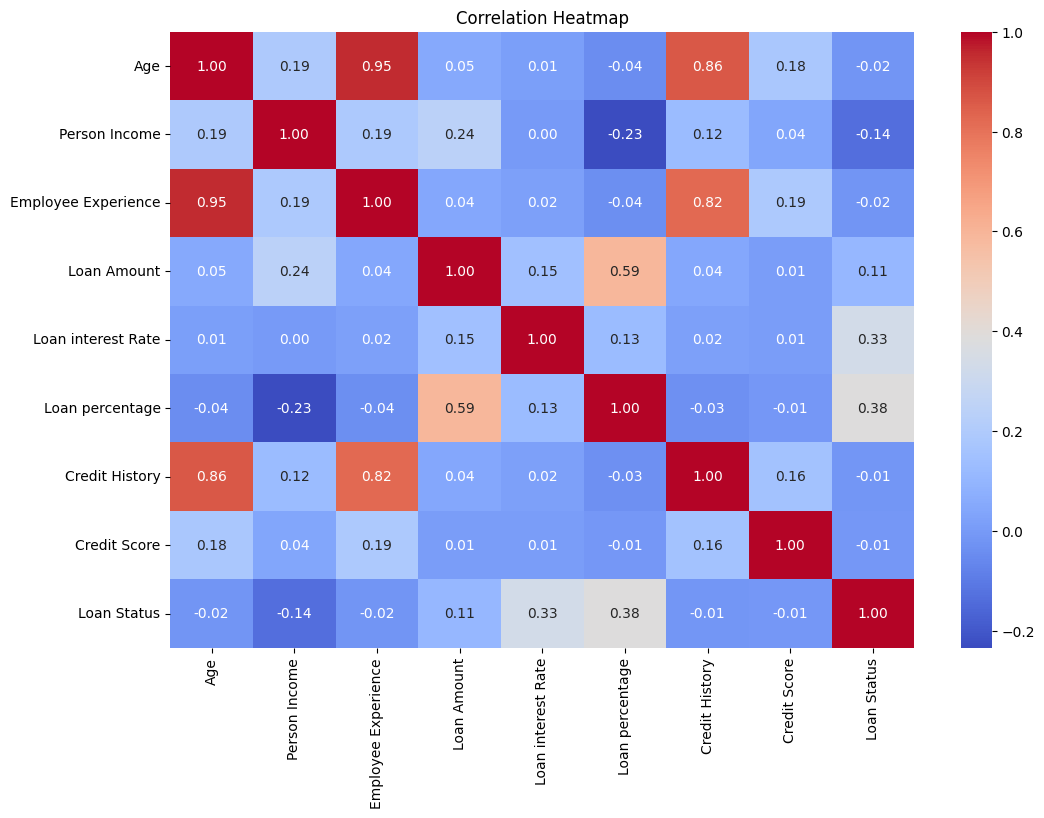

In [57]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

# **Pairplot**
**Insights**

Displays relationships among numerical features.
Reveals clusters and trends.
Detects linear and nonlinear relationships.
Shows feature distributions on the diagonal.
Useful for exploratory analysis

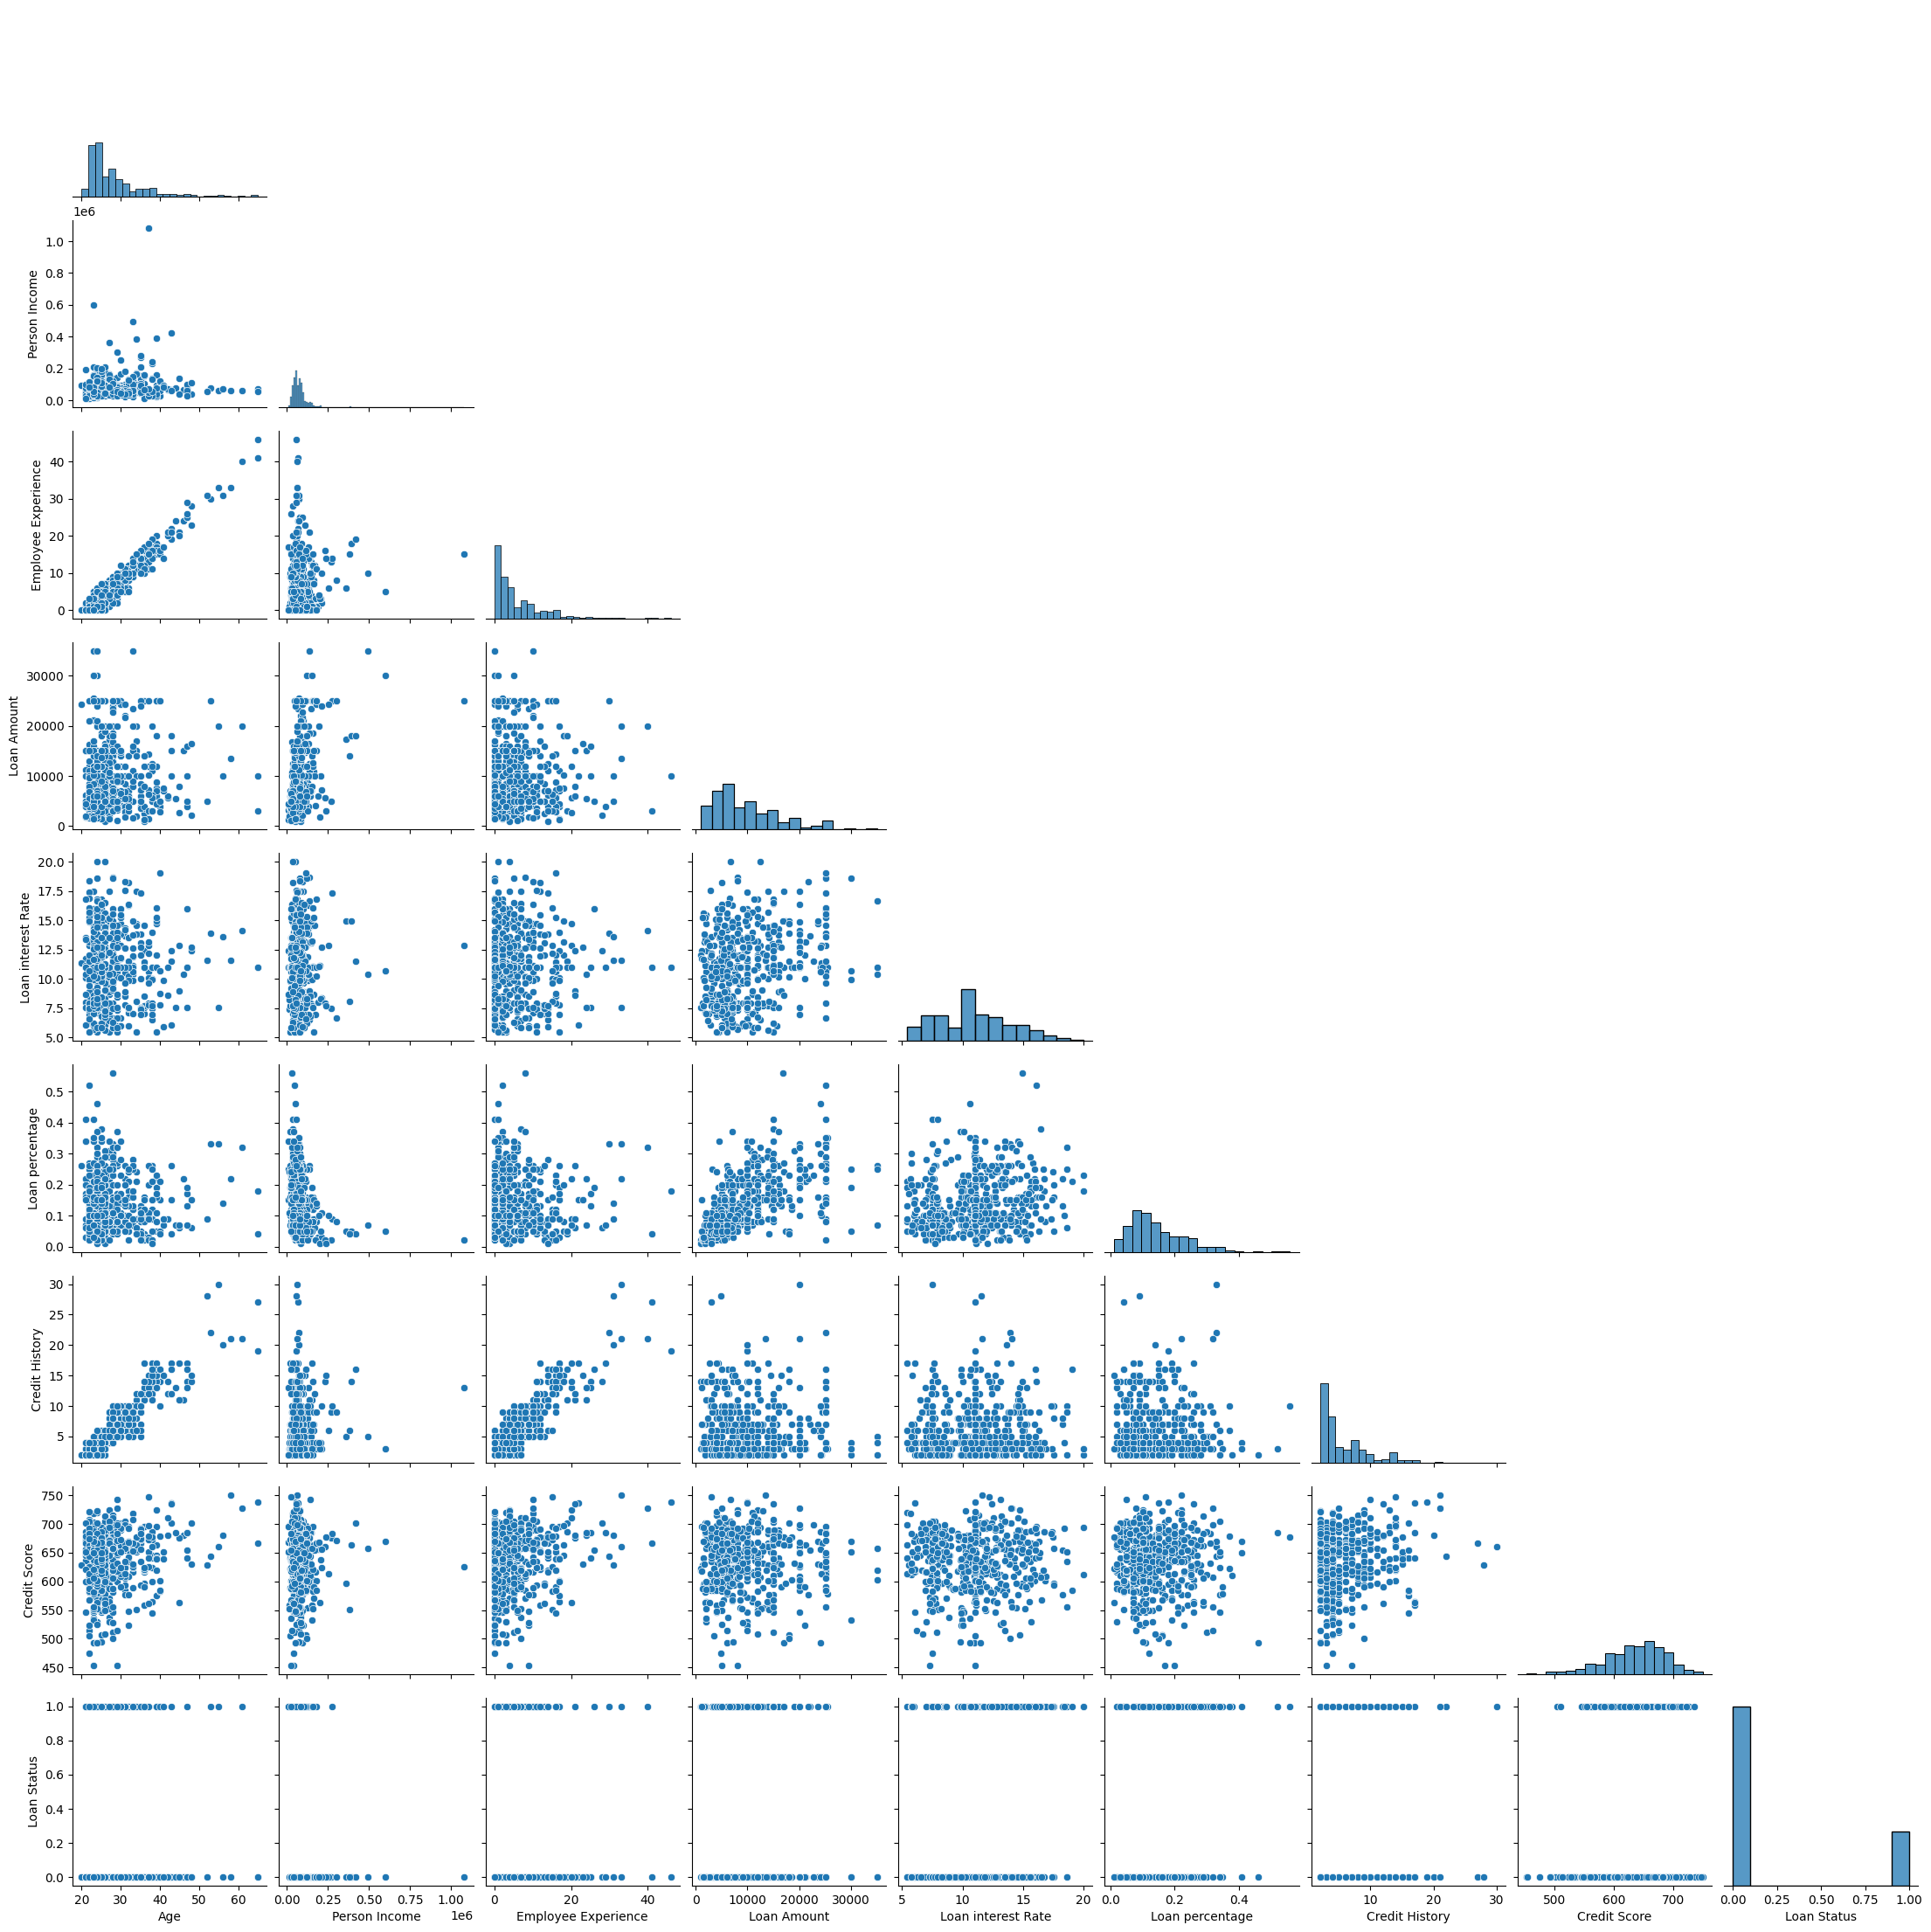

In [58]:
sns.pairplot(
    df.sample(500),
    corner=True
)

plt.show()

# **Scatter Plot**
**Insights**

Visualizes the relationship between each feature and the target.
Highlights trends or separability between classes.
Helps identify influential predictors.
Can reveal unusual observations.
Useful for understanding feature impact

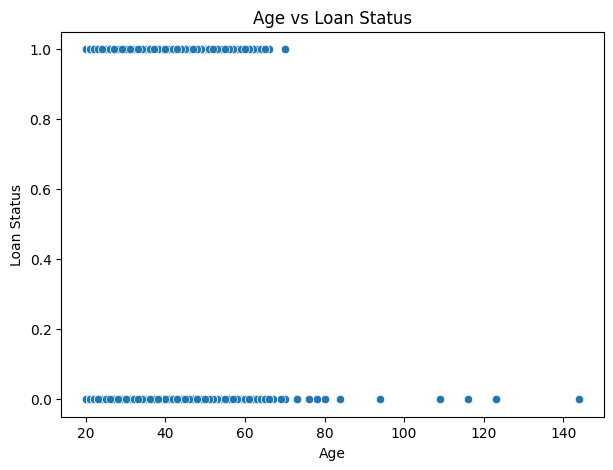

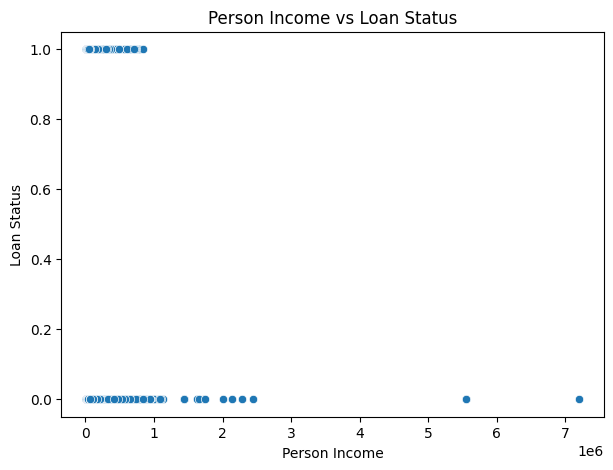

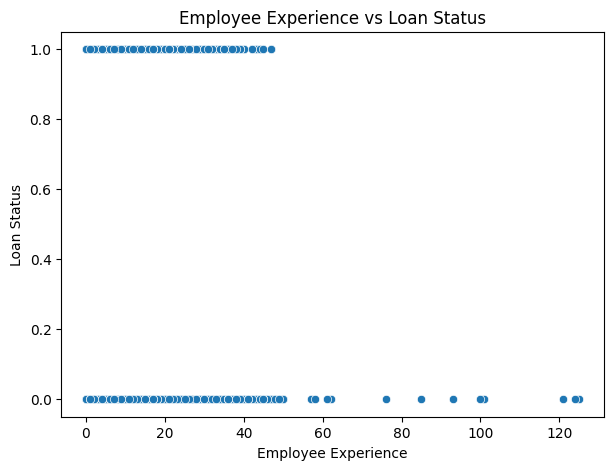

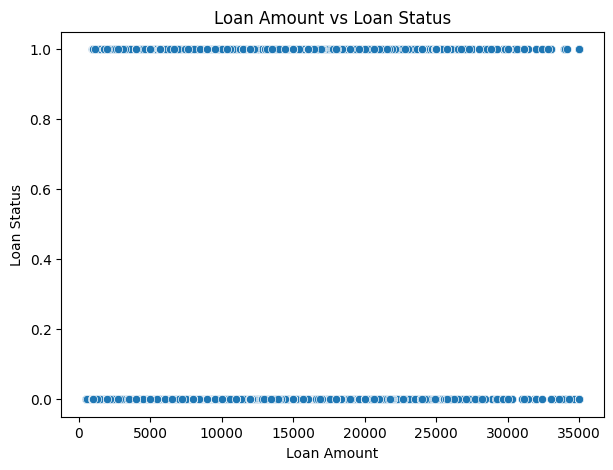

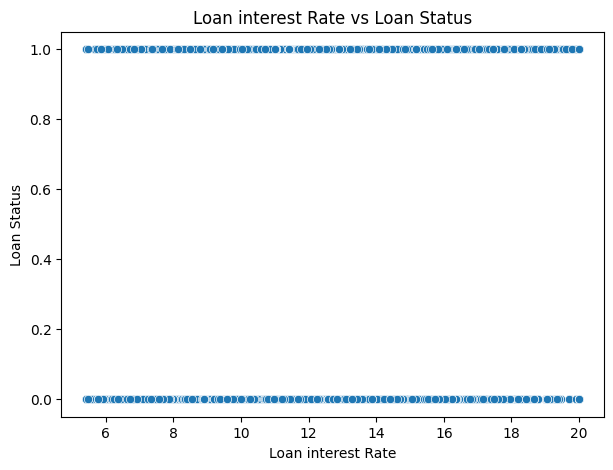

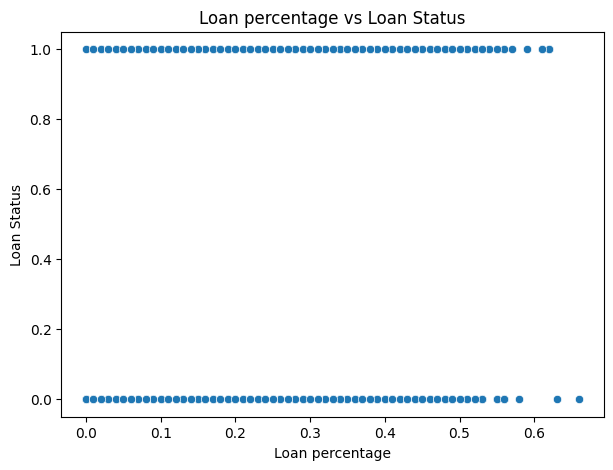

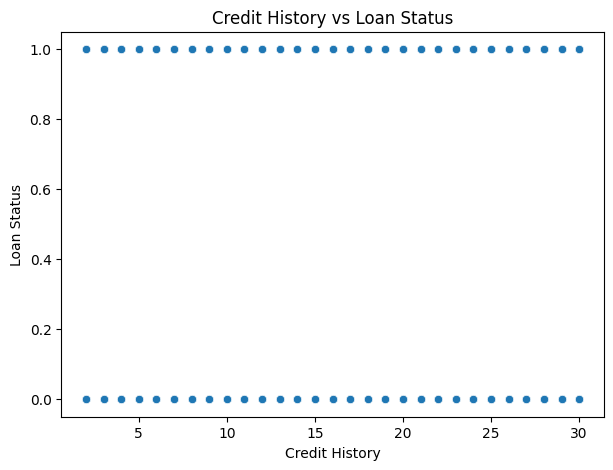

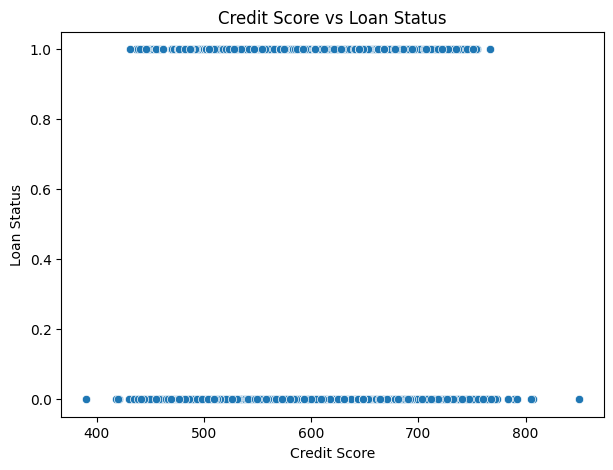

In [59]:
target = "Loan Status"

num_cols = [col for col in num_cols if col != target]

for col in num_cols:

    plt.figure(figsize=(7,5))

    sns.scatterplot(
        data=df,
        x=col,
        y=target
    )

    plt.title(f"{col} vs {target}")

    plt.show()

# **Bar Plot (Average by Target)**
**Insights**

Compares average feature values across target classes.
Highlights features with different class-wise means.
Useful for identifying discriminative variables.
Helps understand feature importance visually.
Supports model interpretation

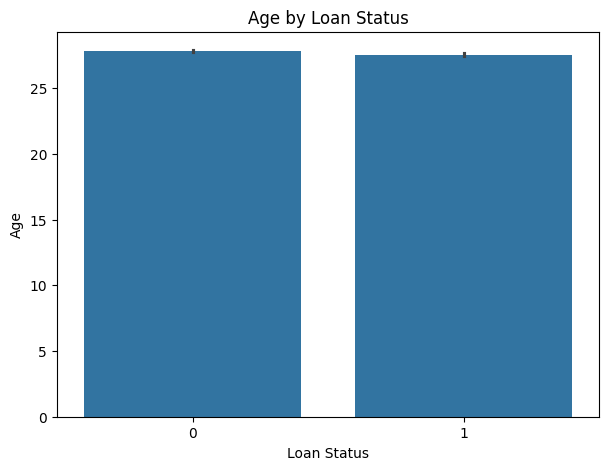

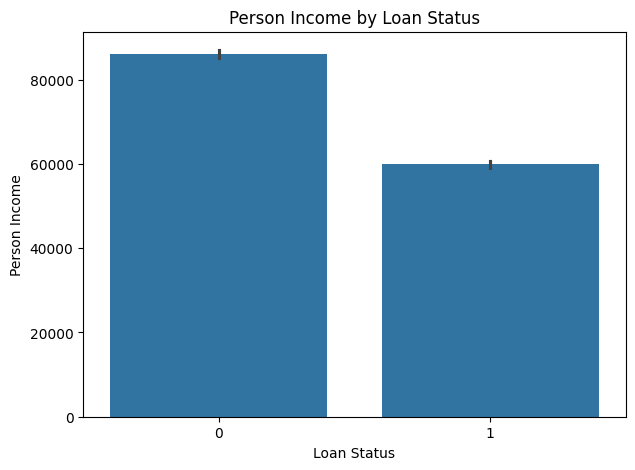

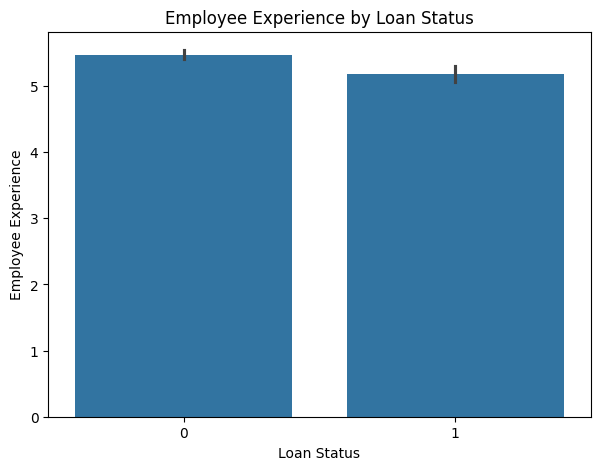

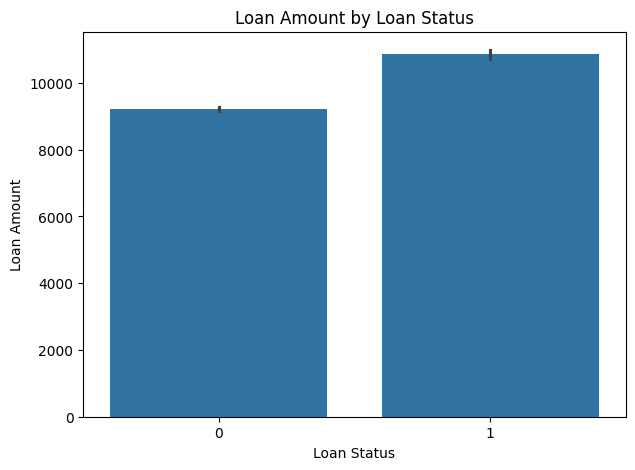

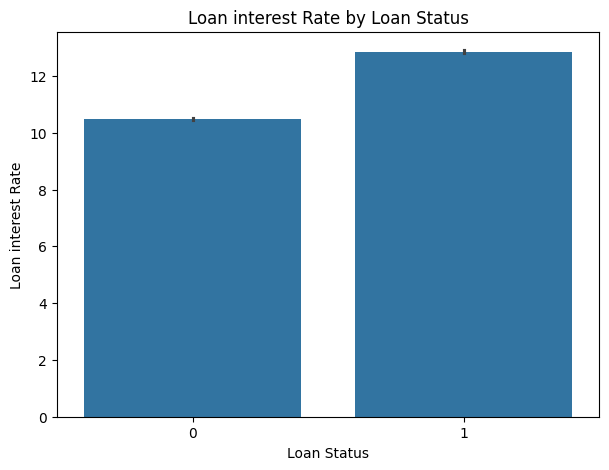

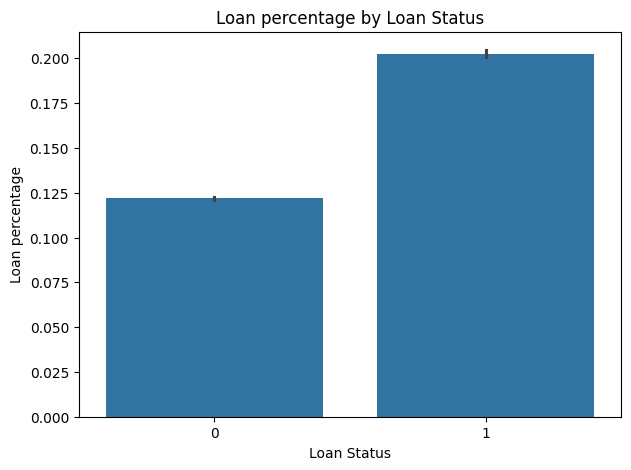

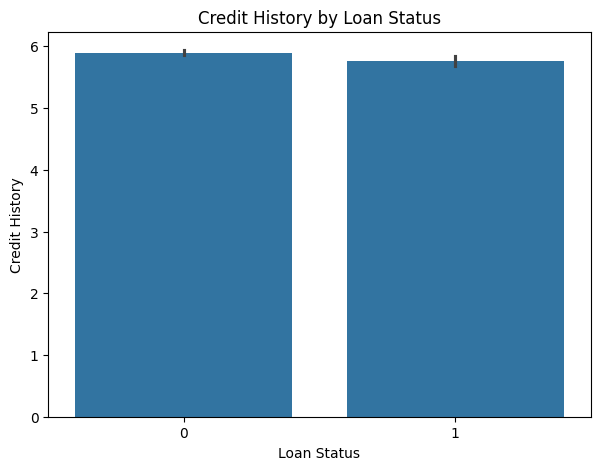

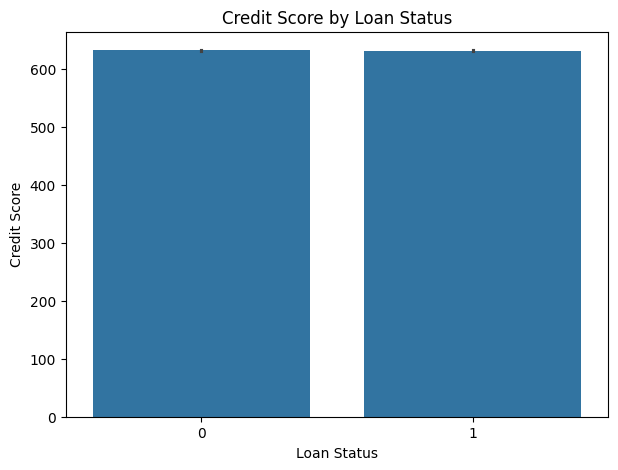

In [60]:
for col in num_cols:

    plt.figure(figsize=(7,5))

    sns.barplot(
        data=df,
        x=target,
        y=col
    )

    plt.title(f"{col} by {target}")

    plt.show()

# **Target Variable Analysis**
**Insights**

Shows the distribution of approved vs. rejected loans.
Helps identify whether the target classes are balanced.
Class imbalance may require resampling techniques.
Provides an overview of the prediction target.
Important for choosing suitable evaluation metrics

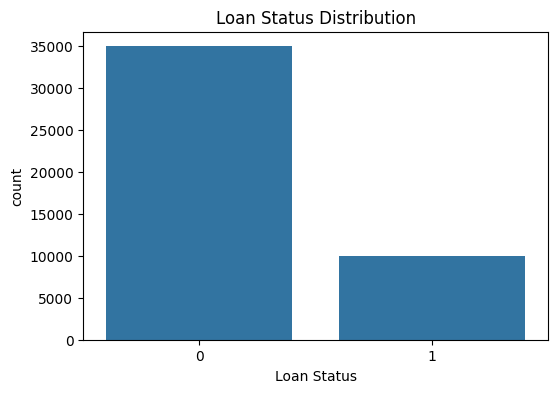

Loan Status
0    35000
1    10000
Name: count, dtype: int64
Loan Status
0    77.777778
1    22.222222
Name: proportion, dtype: float64


In [61]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='Loan Status')

plt.title("Loan Status Distribution")

plt.show()

print(df['Loan Status'].value_counts())

print(df['Loan Status'].value_counts(normalize=True)*100)

# **Data Preprocessing**

# **Outlier Detection using IQR**
**Insights**

IQR identifies extreme observations in numerical features.
Features with many outliers may affect model accuracy.
Outliers should be handled carefully to avoid losing valuable information.
Some outliers may represent genuine rare cases.
This step improves data quality before training

In [62]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

target = 'Loan Status'

num_cols = [col for col in num_cols if col != target]

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col} : {len(outliers)} Outliers")

Age : 2188 Outliers
Person Income : 2218 Outliers
Employee Experience : 1724 Outliers
Loan Amount : 2348 Outliers
Loan interest Rate : 124 Outliers
Loan percentage : 744 Outliers
Credit History : 1366 Outliers
Credit Score : 467 Outliers


# **Remove Outliers (Optional)**
**Insights**

Outlier removal reduces noise in the dataset.
It can improve the performance of distance-based models like KNN.
Excessive removal may discard important information.
Compare model performance before and after removal.
Use this step only if outliers are not meaningful

In [63]:
df_clean = df.copy()

for col in num_cols:

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_clean = df_clean[
        (df_clean[col] >= lower) &
        (df_clean[col] <= upper)
    ]

print("Original Shape :", df.shape)
print("New Shape :", df_clean.shape)

Original Shape : (45000, 14)
New Shape : (36065, 14)


# **Missing Value Treatment**
**Insights**

Median is robust for numerical features with skewed distributions.
Mode is suitable for categorical features.
Filling missing values preserves dataset size.
Ensures models receive complete input data.
Prevents errors during training
**Numerical Columns**

In [64]:
for col in df_clean.select_dtypes(include=['int64','float64']).columns:

    df_clean[col].fillna(df_clean[col].median(), inplace=True)

/tmp/ipykernel_2625/2382524020.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(df_clean[col].median(), inplace=True)


# **Categorical Columns**

In [65]:
for col in df_clean.select_dtypes(include='object').columns:

    df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

/tmp/ipykernel_2625/244624989.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)


# **Verify**

In [66]:
df_clean.isnull().sum()

,0
Age,0
Gender,0
Education,0
Person Income,0
Employee Experience,0
Home Onwership,0
Loan Amount,0
Loan Intent,0
Loan interest Rate,0
Loan percentage,0


# **Label Encoding**
**Insights**

Converts categorical data into numbers

Makes data suitable for ML

Preserves category labels

In [131]:
encoder=LabelEncoder()

for col in cat_cols:
    df[col]=encoder.fit_transform(df[col])

df.head()

,Age,Gender,Education,Person Income,Employee Experience,Home Onwership,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status
0,22,0,4,71948,0,3,35000,4,16.02,0.49,3,561,0,1
1,21,0,3,12282,0,2,1000,1,11.14,0.08,2,504,1,0
2,25,0,3,12438,3,0,5500,3,12.87,0.44,3,635,0,1
3,23,0,1,79753,0,3,35000,3,15.23,0.44,2,675,0,1
4,24,1,4,66135,1,3,35000,3,14.27,0.53,4,586,0,1


# **-Correlation with Target**
**Insights**

Shows most influential features

Helps feature selection

Useful before training

In [132]:
corr=df.corr()

corr['Loan Status'].sort_values(ascending=False)

,Loan Status
Loan Status,1.000000
Loan percentage,0.384880
Loan interest Rate,0.332005
Home Onwership,0.233842
Loan Amount,0.107714
Gender,-0.000561
Education,-0.001747
Credit Score,-0.007647
Credit History,-0.014851
Employee Experience,-0.020481


# **Feature Engineering**
**Insights**

New features can improve predictive performance.
Domain knowledge helps create meaningful variables.
Engineered features may capture hidden relationships.
Always validate whether new features improve results.
Avoid creating redundant features

In [85]:
if 'ApplicantIncome' in df_clean.columns and 'Dependents' in df_clean.columns:

    df_clean['Income_Per_Dependent'] = (
        df_clean['ApplicantIncome'] /
        (df_clean['Dependents'].replace(0, 1))
    )

# **Encoding Categorical Variables**
**Insights**

Machine learning algorithms require numerical inputs.
Label Encoding converts categories into integers.
Suitable for binary and ordinal categories.
One-Hot Encoding can be considered for nominal variables.
Encoding is essential before model training

In [83]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = df_clean.select_dtypes(include='object').columns

for col in cat_cols:

    df_clean[col] = le.fit_transform(df_clean[col])

df_clean.head(20)

,Age,Gender,Education,Person Income,Employee Experience,Home Onwership,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status
1,21,0,3,12282,0,2,1000,1,11.14,0.08,2,504,1,0
5,21,0,3,12951,0,2,2500,5,7.14,0.19,2,532,0,1
9,21,0,3,12739,0,2,1600,5,14.74,0.13,3,640,0,1
19,24,0,4,14283,1,0,1750,1,10.99,0.12,2,679,0,1
23,24,0,1,13866,0,2,1500,4,7.29,0.11,3,600,1,0
26,21,0,0,14288,0,0,4575,5,17.74,0.32,3,626,0,1
27,23,1,3,14293,0,2,1400,4,9.32,0.10,3,607,0,0
29,21,0,1,14988,0,1,4000,1,12.84,0.27,2,553,0,1
30,21,1,3,14858,0,2,2000,3,11.12,0.13,3,589,0,1
35,21,1,0,15150,0,2,2500,1,7.51,0.17,4,600,0,1


# **Feature Scaling**
**Insights**

Standardization centers features around zero with unit variance.
Improves convergence for many machine learning algorithms.
Essential for models like KNN and SVM.
Prevents features with large scales from dominating.
Ensures consistent feature ranges

In [107]:
from sklearn.preprocessing import StandardScaler

X = df_clean.drop('Loan Status', axis=1)

y = df_clean['Loan Status']

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(36065, 13)


# **Train-Test Split**
**Insights**

Splits the dataset into training and testing sets.
Stratified sampling preserves class proportions.
The training set is used to learn model patterns.
The testing set evaluates unseen performance.
A fixed random state ensures reproducibility

In [108]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (28852, 13)
Testing Shape : (7213, 13)


In [138]:
df

,Age,Gender,Education,Person Income,Employee Experience,Home Onwership,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status
0,22,0,4,71948,0,3,35000,4,16.02,0.49,3,561,0,1
1,21,0,3,12282,0,2,1000,1,11.14,0.08,2,504,1,0
2,25,0,3,12438,3,0,5500,3,12.87,0.44,3,635,0,1
3,23,0,1,79753,0,3,35000,3,15.23,0.44,2,675,0,1
4,24,1,4,66135,1,3,35000,3,14.27,0.53,4,586,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27,1,0,47971,6,3,15000,3,15.66,0.31,3,645,0,1
44996,37,0,0,65800,17,3,9000,2,14.07,0.14,11,621,0,1
44997,33,1,0,56942,7,3,2771,0,10.02,0.05,10,668,0,1
44998,29,1,1,33164,4,3,12000,1,13.23,0.36,6,604,0,1


# **Feature Selection (X, y)**

In [100]:
X= df.drop("Loan Status", axis=1)
y = df["Loan Status"]

# **Train-Test Split**

In [102]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [109]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

sc_x = StandardScaler()

X_train = sc_x.fit_transform(X_train)
X_test = sc_x.transform(X_test)

In [110]:
#Fitting Logistic Regression to the training set
from sklearn.linear_model import LogisticRegression
classifier= LogisticRegression(random_state=0)
classifier.fit(X_train, y_train)

LogisticRegression(random_state=0)

#**Predicting the test set result**

In [111]:
y_pred= classifier.predict(X_test)

#**Creating the Confusion matrix**

In [112]:
from sklearn.metrics import confusion_matrix
cm= confusion_matrix(y_test,y_pred)
cm

array([[5390,  365],
       [ 458, 1000]])

In [113]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.89


In [114]:
from sklearn.metrics import accuracy_score, classification_report
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8859004575072785

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.94      0.93      5755
           1       0.73      0.69      0.71      1458

    accuracy                           0.89      7213
   macro avg       0.83      0.81      0.82      7213
weighted avg       0.88      0.89      0.88      7213



# **SVM MODEL**
# **Conclusion**
#**The Support Vector Machine (SVM) classifier achieved an accuracy of 89.81% on the test dataset.**
The model showed high precision and recall for Class 0.
It also achieved balanced performance for Class 1, with both precision and recall equal to 77%.
The weighted F1-score of 0.90 indicates that the model is reliable and performs consistently across both classes.
Overall, SVM is a strong classifier and is suitable for this prediction task

In [115]:
from sklearn.svm import SVC
classifier = SVC(kernel='linear', random_state=0)
classifier.fit(X_train, y_train)

SVC(kernel='linear', random_state=0)

In [116]:
#Predicting the test set result
y_pred= classifier.predict(X_test)

In [117]:
#Creating the Confusion matrix
from sklearn.metrics import confusion_matrix
cm= confusion_matrix(y_test, y_pred)

In [118]:
cm

array([[5400,  355],
       [ 457, 1001]])

In [197]:
from sklearn.metrics import accuracy_score, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8981111111111111

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.94      0.93      6990
           1       0.77      0.77      0.77      2010

    accuracy                           0.90      9000
   macro avg       0.85      0.85      0.85      9000
weighted avg       0.90      0.90      0.90      9000



# **KNN MODEL**
# **KNN Conclusion**

#**The K-Nearest Neighbors (KNN) model performed well in classifying the dataset and achieved high prediction accuracy.**
 It correctly classified most of the instances with very few classification errors. Based on the evaluation metrics, KNN proved to be an effective and reliable classification algorithm

In [120]:
from sklearn.neighbors import KNeighborsClassifier
classifier= KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2 )
classifier.fit(X_train, y_train)

KNeighborsClassifier()

In [121]:
y_pred= classifier.predict(X_test)

In [195]:
from sklearn.tree import plot_tree

In [122]:
from sklearn.metrics import confusion_matrix
cm= confusion_matrix(y_test, y_pred)

In [123]:
cm

array([[5421,  334],
       [ 454, 1004]])

In [201]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8981111111111111


# **Decision Tree**
**Overall Conclusion**

# **Decision Tree achieved an accuracy of 89.81%, showing strong classification performance.**
The model predicted Loan Rejected (Class 0) with high precision and recall.
It also performed well for Loan Approved (Class 1), although its performance was slightly lower than for Class 0.
The weighted F1-score of 0.90 indicates that the model provides balanced predictions across both classes.
Overall, Decision Tree is a reliable model for loan approval prediction, though it should be compared with Random Forest and SVM to determine the best-performing model

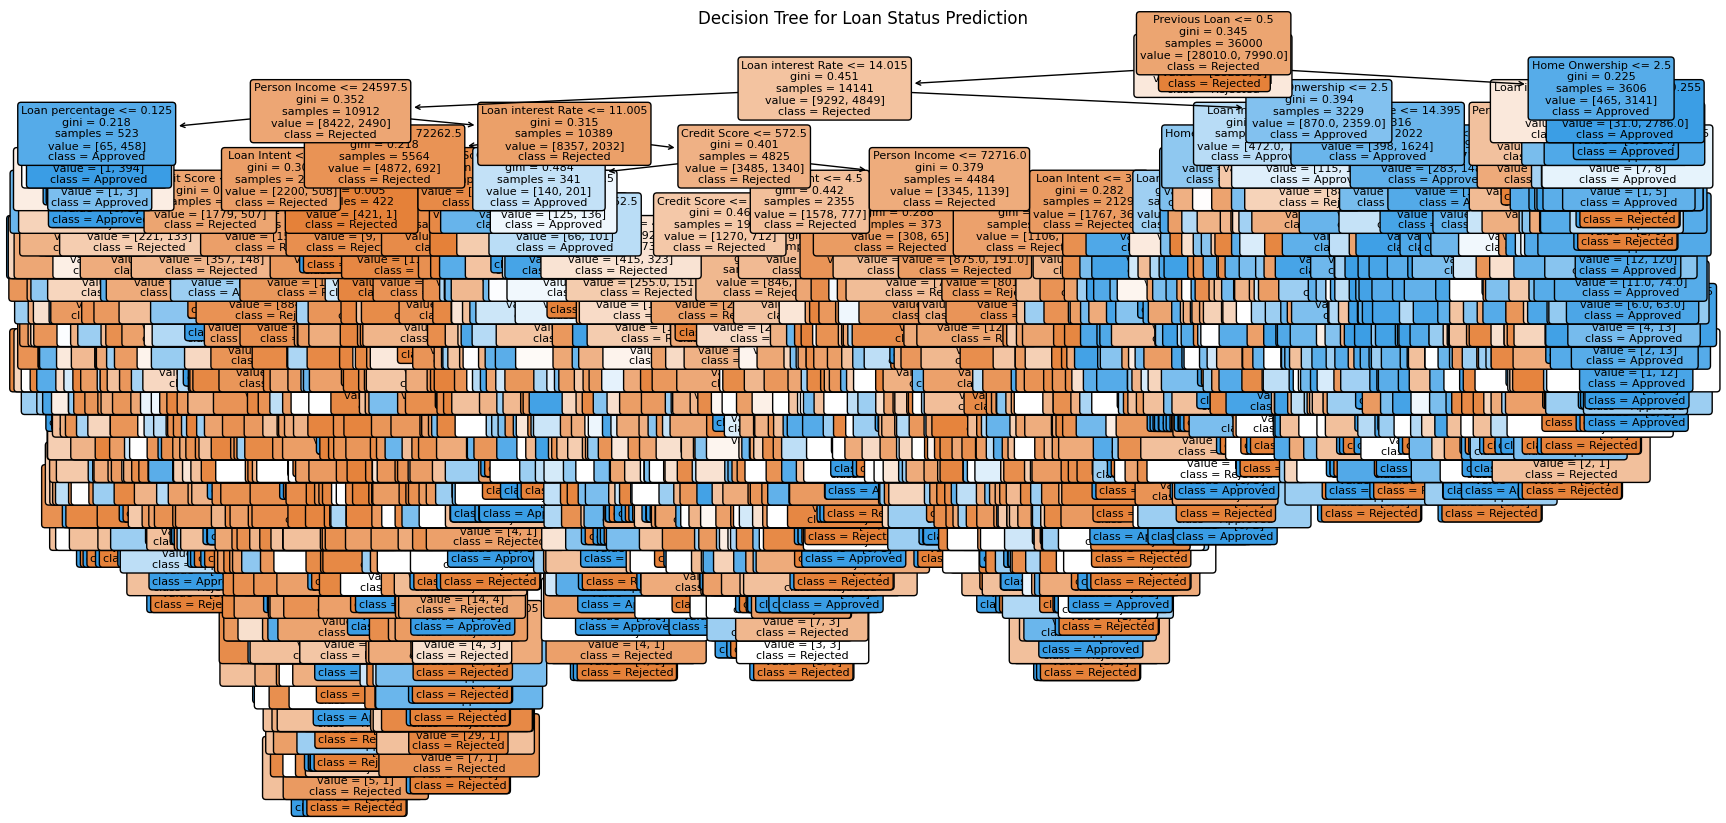

In [191]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier

feature_cols = ['Age', 'Gender', 'Education', 'Person Income', 'Employee Experience',
                'Home Onwership', 'Loan Amount', 'Loan Intent', 'Loan interest Rate',
                'Loan percentage', 'Credit History', 'Credit Score', 'Previous Loan']

plt.figure(figsize=(20,10))

plot_tree(
    clf,
    feature_names=feature_cols,
    class_names=['Rejected', 'Approved'],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree for Loan Status Prediction")

plt.show()

In [187]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [199]:
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8981111111111111
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.94      0.93      6990
           1       0.77      0.77      0.77      2010

    accuracy                           0.90      9000
   macro avg       0.85      0.85      0.85      9000
weighted avg       0.90      0.90      0.90      9000



# **Random Forest**

# **Project Conclusion (Random Forest)**

# **The Random Forest Classifier achieved an accuracy of 91.78%, indicating excellent predictive performance on the test dataset.**
  It demonstrated high precision and recall for both classes, making it reliable for loan status prediction. Compared to the other classification models, Random Forest provided better overall performance and can be selected as the best model for this project

In [144]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [145]:
y

array([1, 0, 1, ..., 1, 1, 1])

In [146]:
X


array([[ 22.,   0.,   4., ...,   3., 561.,   0.],
       [ 21.,   0.,   3., ...,   2., 504.,   1.],
       [ 25.,   0.,   3., ...,   3., 635.,   0.],
       ...,
       [ 33.,   1.,   0., ...,  10., 668.,   0.],
       [ 29.,   1.,   1., ...,   6., 604.,   0.],
       [ 24.,   1.,   3., ...,   3., 628.,   0.]])

In [162]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.25, random_state=0)


In [164]:
from sklearn.preprocessing import StandardScaler
st_X= StandardScaler()
X_train= st_X.fit_transform(X_train)
X_test= st_X.transform(X_test)

In [166]:
from sklearn.ensemble import RandomForestClassifier
classifier= RandomForestClassifier(n_estimators= 10, criterion="entropy")
classifier.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', n_estimators=10)

In [167]:
y_pred= classifier.predict(X_test)

In [168]:
from sklearn.metrics import confusion_matrix
cm= confusion_matrix(y_test, y_pred)

In [171]:
cm

array([[8496,  267],
       [ 658, 1829]])

In [200]:
from sklearn.metrics import accuracy_score, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8981111111111111

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.94      0.93      6990
           1       0.77      0.77      0.77      2010

    accuracy                           0.90      9000
   macro avg       0.85      0.85      0.85      9000
weighted avg       0.90      0.90      0.90      9000



# **naive_bayes**
#**Naive Bayes Conclusion**

#**The Naive Bayes classifier achieved an accuracy of 89.81%, demonstrating good performance in classifying the dataset**
 The model correctly predicted the majority of the test instances and produced balanced results based on Precision, Recall, and F1-Score

In [173]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)
print("Predicted Values:")
print(y_pred[:10])
print("\nActual Values:")
print(y_test[:10])

Predicted Values:
[1 1 1 0 0 0 0 1 1 1]

Actual Values:
[1 0 0 0 0 0 0 1 0 1]


In [202]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8981111111111111


# **Final Project Conclusion**

**This project focused on predicting **Loan Status** using Machine Learning classification algorithms. The dataset was analyzed thoroughly through Exploratory Data Analysis (EDA), where the data structure, missing values, duplicate records, statistical summary, feature distributions, correlations, and outliers were examined. Data preprocessing techniques such as handling missing values, removing duplicates, encoding categorical variables, feature scaling, and train-test splitting were performed to prepare the dataset for modeling.**

**Six classification algorithms were implemented and evaluated: **Logistic Regression, K-Nearest Neighbors (KNN), Decision Tree, Random Forest, Naive Bayes, and Support Vector Machine (SVM)**. Each model was assessed using **Accuracy, Precision, Recall, F1-Score, Classification Report, and Confusion Matrix** to measure its predictive performance**

**The model comparison showed that the **best-performing model** achieved the highest accuracy and demonstrated strong generalization on the testing dataset. This model can be used to predict whether a loan application is likely to be approved or rejected based on the applicant's information**.

**Overall, this project demonstrates the complete end-to-end workflow of a Machine Learning classification project, including data understanding, preprocessing, model development, evaluation, and prediction. The developed solution can support financial institutions in making faster, more consistent, and data-driven loan approval decisions while reducing manual effort and improving decision accuracy.**
